In [21]:
!pip install dgeb datasets -q
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from itertools import product
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score


In [22]:
from datasets import load_dataset

# Dataset Link: https://huggingface.co/tattabio/datasets?p=0
ecoli  = load_dataset("tattabio/ecoli_operonic_pair")
cyano  = load_dataset("tattabio/cyano_operonic_pair")
vibrio = load_dataset("tattabio/vibrio_operonic_pair")

print("E. coli columns:", ecoli["train"].features)
print("Cyano columns:",   cyano["train"].features)
print("Vibrio columns:",  vibrio["train"].features)

E. coli columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}
Cyano columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}
Vibrio columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}


In [23]:

def build_pairs(dataset_split):
    seqs   = dataset_split["Sequence"]
    labels = dataset_split["Label"]

    seq_a, seq_b, pair_labels = [], [], []
    for i in range(len(seqs) - 1):
        seq_a.append(seqs[i])
        seq_b.append(seqs[i + 1])
        pair_labels.append(labels[i])

    return seq_a, seq_b, np.array(pair_labels)

seq_a_ec, seq_b_ec, labels_ec = build_pairs(ecoli["train"])
seq_a_cy, seq_b_cy, labels_cy = build_pairs(cyano["train"])
seq_a_vi, seq_b_vi, labels_vi = build_pairs(vibrio["train"])

print(f"E. coli pairs: {len(labels_ec):,}, positive rate: {labels_ec.mean():.1%}")
print(f"Cyano pairs:   {len(labels_cy):,}, positive rate: {labels_cy.mean():.1%}")
print(f"Vibrio pairs:  {len(labels_vi):,}, positive rate: {labels_vi.mean():.1%}")

E. coli pairs: 4,314, positive rate: 40.5%
Cyano pairs:   2,610, positive rate: 28.2%
Vibrio pairs:  2,573, positive rate: 34.6%


In [24]:
print(ecoli["train"]["Label"][:10])

[1, 1, 1, 0, 0, 0, 0, 0, 0, 0]


In [25]:
AA = "ACDEFGHIKLMNPQRSTVWY"
KMERS = {"".join(p): i for i, p in enumerate(product(AA, repeat=3))}

def kmer_vector(seq, k=3):
    """Convert amino acid sequence to normalized k-mer frequency vector."""
    vec = np.zeros(len(KMERS), dtype=np.float32)
    seq = seq.upper()
    count = 0
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in KMERS:
            vec[KMERS[kmer]] += 1
            count += 1
    if count > 0:
        vec /= count
    return vec

def encode_pairs(seq_a_list, seq_b_list, label=""):
    print(f"Encoding {label} sequences")
    vA = np.array([kmer_vector(s) for s in seq_a_list])
    vB = np.array([kmer_vector(s) for s in seq_b_list])
    X  = np.concatenate([vA, vB, np.abs(vA - vB)], axis=1)
    print(f"Done. Shape: {X.shape}")
    return X

X_ec = encode_pairs(seq_a_ec, seq_b_ec, "E. coli")
X_cy = encode_pairs(seq_a_cy, seq_b_cy, "Cyano")
X_vi = encode_pairs(seq_a_vi, seq_b_vi, "Vibrio")

Encoding E. coli sequences
Done. Shape: (4314, 24000)
Encoding Cyano sequences
Done. Shape: (2610, 24000)
Encoding Vibrio sequences
Done. Shape: (2573, 24000)


In [26]:
from sklearn.model_selection import train_test_split

X_ec_train, X_ec_test, y_ec_train, y_ec_test = train_test_split(
    X_ec, labels_ec, test_size=0.2, stratify=labels_ec, random_state=42
)
X_cy_train, X_cy_test, y_cy_train, y_cy_test = train_test_split(
    X_cy, labels_cy, test_size=0.2, stratify=labels_cy, random_state=42
)
X_vi_train, X_vi_test, y_vi_train, y_vi_test = train_test_split(
    X_vi, labels_vi, test_size=0.2, stratify=labels_vi, random_state=42
)

print(f"E. coli  — train: {X_ec_train.shape[0]:,}  test: {X_ec_test.shape[0]:,}")
print(f"Cyano    — train: {X_cy_train.shape[0]:,}  test: {X_cy_test.shape[0]:,}")
print(f"Vibrio   — train: {X_vi_train.shape[0]:,}  test: {X_vi_test.shape[0]:,}")

E. coli  — train: 3,451  test: 863
Cyano    — train: 2,088  test: 522
Vibrio   — train: 2,058  test: 515


In [27]:
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import cross_val_score

alphas = [0.01, 0.1, 0.5, 1.0]

best_alpha = None
best_ap = -1

print("ComplementNB alpha search")

for alpha in alphas:
    model = ComplementNB(alpha=alpha)

    cv_scores = cross_val_score(
        model,
        X_ec_train,
        y_ec_train,
        cv=5,
        scoring="average_precision"
    )

    avg_ap = cv_scores.mean()

    print("alpha:", alpha, "mean AP:", round(avg_ap, 4))

    if avg_ap > best_ap:
        best_ap = avg_ap
        best_alpha = alpha

print()
print("Best alpha:", best_alpha)
print("Best CV average precision:", round(best_ap, 4))

ComplementNB alpha search
alpha: 0.01 mean AP: 0.5297
alpha: 0.1 mean AP: 0.4927
alpha: 0.5 mean AP: 0.4482
alpha: 1.0 mean AP: 0.4361

Best alpha: 0.01
Best CV average precision: 0.5297


In [28]:
Cs = [0.01, 0.1, 1, 10, 100]

best_C = None
best_ap = -1

print("Logistic Regression C search")

for C in Cs:
    model = LogisticRegression(
        C=C,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_ec_train,
        y_ec_train,
        cv=5,
        scoring="average_precision"
    )

    avg_ap = cv_scores.mean()

    print("C:", C, "mean AP:", round(avg_ap, 4))

    if avg_ap > best_ap:
        best_ap = avg_ap
        best_C = C

print()
print("Best C:", best_C)
print("Best CV average precision:", round(best_ap, 4))

Logistic Regression C search
C: 0.01 mean AP: 0.4656
C: 0.1 mean AP: 0.5349
C: 1 mean AP: 0.5349
C: 10 mean AP: 0.5349
C: 100 mean AP: 0.5344

Best C: 10
Best CV average precision: 0.5349


In [29]:
def train_and_evaluate(model):
    """
    Train and test the model separately for each dataset.
    """
    results = {}

    datasets = [
        ("E. coli", X_ec_train, y_ec_train, X_ec_test, y_ec_test),
        ("Cyano", X_cy_train, y_cy_train, X_cy_test, y_cy_test),
        ("Vibrio", X_vi_train, y_vi_train, X_vi_test, y_vi_test),
    ]

    for name, X_train, y_train, X_test, y_test in datasets:
        model.fit(X_train, y_train)

        y_score = model.predict_proba(X_test)[:, 1]

        ap = average_precision_score(y_test, y_score)
        results[name] = round(ap, 4)

    return results

best_alpha_cnb = 0.01
best_C_lr = 10
cnb_model = ComplementNB(alpha=best_alpha_cnb)

lr_model = LogisticRegression(
    C=best_C_lr,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

cnb_results = train_and_evaluate(cnb_model)
lr_results = train_and_evaluate(lr_model)

print("CNB results:", cnb_results)
print("Logistic Regression results:", lr_results)

CNB results: {'E. coli': np.float64(0.4884), 'Cyano': np.float64(0.3271), 'Vibrio': np.float64(0.4555)}
Logistic Regression results: {'E. coli': np.float64(0.5024), 'Cyano': np.float64(0.3204), 'Vibrio': np.float64(0.4636)}


In [30]:
dgeb_baselines = {
    "E. coli": {
        "ESM2-650M": 0.573,
        "ESM3": 0.577,
        "ProtTrans": 0.618
    },
    "Cyano": {
        "ESM2-650M": 0.373,
        "ESM3": 0.390,
        "ProtTrans": 0.409
    },
    "Vibrio": {
        "ESM2-650M": 0.483,
        "ESM3": 0.497,
        "ProtTrans": 0.543
    }
}

rows = []

for dataset in ["E. coli", "Cyano", "Vibrio"]:
    rows.append({
        "Dataset": dataset,
        "CNB": cnb_results[dataset],
        "Logistic Regression": lr_results[dataset],
        "ESM2-650M": dgeb_baselines[dataset]["ESM2-650M"],
        "ESM3": dgeb_baselines[dataset]["ESM3"],
        "ProtTrans": dgeb_baselines[dataset]["ProtTrans"]
    })

results_df = pd.DataFrame(rows)
results_df = results_df.set_index("Dataset")

print()
print("Average precision comparison")
print(results_df.to_string())


Average precision comparison
            CNB  Logistic Regression  ESM2-650M   ESM3  ProtTrans
Dataset                                                          
E. coli  0.4884               0.5024      0.573  0.577      0.618
Cyano    0.3271               0.3204      0.373  0.390      0.409
Vibrio   0.4555               0.4636      0.483  0.497      0.543


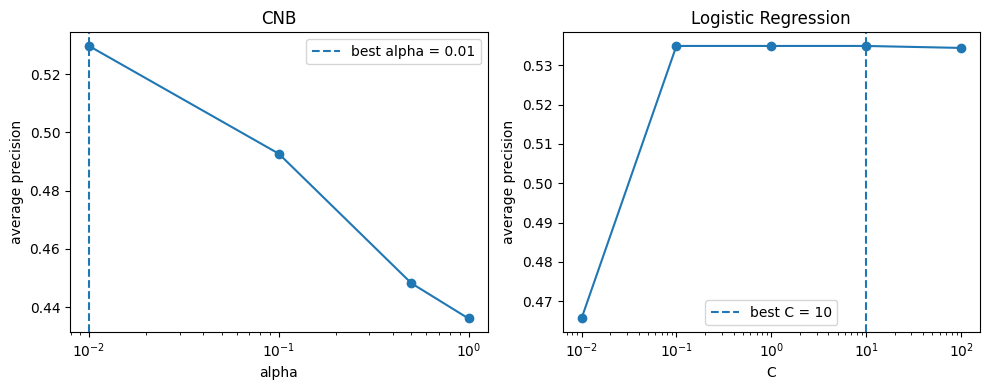

In [31]:
import matplotlib.pyplot as plt

# data from cross-validation
alphas = [0.01, 0.1, 0.5, 1.0]
cnb_scores = [0.5297, 0.4927, 0.4482, 0.4361]

Cs = [0.01, 0.1, 1, 10, 100]
lr_scores = [0.4656, 0.5349, 0.5349, 0.5349, 0.5344]

plt.figure(figsize=(10, 4))

# CNB plot
plt.subplot(1, 2, 1)
plt.plot(alphas, cnb_scores, marker="o")
plt.axvline(0.01, linestyle="--", label="best alpha = 0.01")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("average precision")
plt.title("CNB")
plt.legend()

# logistic regression plot
plt.subplot(1, 2, 2)
plt.plot(Cs, lr_scores, marker="o")
plt.axvline(10, linestyle="--", label="best C = 10")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("average precision")
plt.title("Logistic Regression")
plt.legend()

plt.tight_layout()
plt.savefig("hyperparameter_search.png", dpi=150)
plt.show()

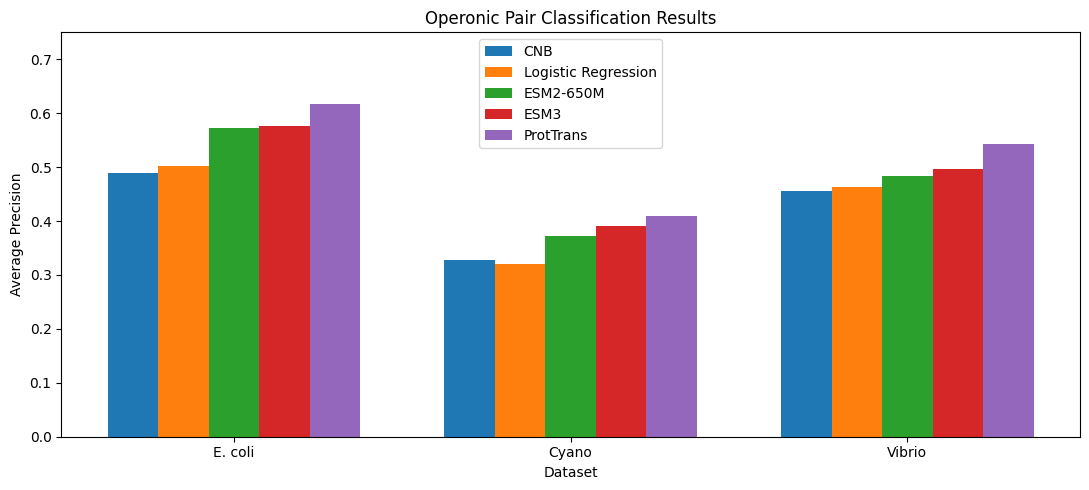

In [32]:
import numpy as np
import matplotlib.pyplot as plt

datasets = ["E. coli", "Cyano", "Vibrio"]

methods = {
    "CNB": [0.4884, 0.3271, 0.4555],
    "Logistic Regression": [0.5024, 0.3204, 0.4636],
    "ESM2-650M": [0.573, 0.373, 0.483],
    "ESM3": [0.577, 0.390, 0.497],
    "ProtTrans": [0.618, 0.409, 0.543],
}

x = np.arange(len(datasets))
width = 0.15

plt.figure(figsize=(11, 5))

for i, (method, scores) in enumerate(methods.items()):
    plt.bar(x + i * width, scores, width, label=method)

plt.xlabel("Dataset")
plt.ylabel("Average Precision")
plt.title("Operonic Pair Classification Results")
plt.xticks(x + width * 2, datasets)
plt.ylim(0, 0.75)
plt.legend()

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()